(04-18-fama-french)=

# Fama-French 1992/1993

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1992–2000.

**Wat we al weten.** Na 1963 is de security market line van [het CAPM](#02-08-capm)
vlak: op de 25 size/BM-portefeuilles van French is het intercept 1,16% per maand en
verwerpt GRS het model met $F = 4{,}20$. [Roll](#03-14-roll) liet zien dat zo'n
verwerping alleen de index treft, en [Basu, Banz en Rosenberg](#03-16-vroege-anomalieen)
vonden losse anomalieën zonder model. [](#03-17-termijnstructuur-real-options) keek naar
de prijs van de tijd; hier keren we terug naar de cross-sectie van aandelen.

**Welke vraag staat open.** Welke kenmerken blijven over als je ze allemaal
tegelijk naast bèta zet, en kun je van die kenmerken een model maken dat de
cross-sectie van gemiddelde rendementen beprijst?
```

## Overzicht

In juni 1992 publiceerden Eugene Fama en Kenneth French in *The Journal of Finance* het
artikel {cite}`FamaFrench1992` dat Santa-Clara beschrijft als *"the paper that ended the
CAPM as a working empirical model"* {cite}`SantaClara2026`. Volgens de samenvatting
vangen twee eenvoudig te meten variabelen, marktwaarde en boekwaarde gedeeld door
marktwaarde (B/M), samen de variatie in gemiddelde rendementen die eerder aan bèta, size,
schuldgraad, B/M en E/P werd toegeschreven, en is het verband tussen bèta en gemiddeld
rendement vlak zodra de toets variatie in bèta toelaat die niet met size samenhangt. Een
jaar later maakten ze er een model van {cite}`FamaFrench1993`: de markt, een portefeuille
die kleine aandelen koopt en grote verkoopt (SMB, *small minus big*) en een die aandelen
met een hoge B/M koopt en met een lage verkoopt (HML, *high minus low*).

Die twee artikelen draaiden de epistemische status van het vak om, motief 3 in zijn
scherpste vorm. Het CAPM was een theorie met een toets; het driefactormodel is een
samenvatting van feiten die op een theorie wacht. Fama en French lazen SMB en HML als
risicofactoren in de geest van het ICAPM en de APT, maar geen van beide theorieën wees ze
aan, en volgens Santa-Clara had het succes van het model niets te danken aan de stelling
van Ross en alles aan het feit dat het paste {cite}`SantaClara2026`. Wat paste, moest
daarna worden verklaard: financiële nood {cite}`ChanChen1991,FamaFrench1995` of
extrapolatie {cite}`LakonishokShleiferVishny1994`, covarianties of kenmerken
{cite}`DanielTitman1997,DavisFamaFrench2000`, en de vraag of een model dat uit dezelfde
sorteringen is gebouwd als de portefeuilles die het verklaart, iets toetst
{cite}`LewellenNagelShanken2010`.

We bouwen SMB en HML met de hand, laten zien wanneer een tijdreekstoets met
verhandelbare factoren een SDF-toets is, en bewijzen twee resultaten die elke tabel
relativeren: zwak gecorreleerde factoren geven dezelfde cross-sectionele fit, en een
wereld waarin het kenmerk wordt beloond, is op gesorteerde portefeuilles niet te
onderscheiden van een wereld waarin de covariantie wordt beloond. Aan het eind repliceren
we tabel 9a van Fama en French (1993), benaderen we tabel III van Fama en French (1992)
met honderd portefeuilles, en volgen we SMB en HML per decennium en na publicatie.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Leg de drie bevindingen uit [](#03-16-vroege-anomalieen) naast elkaar. Aandelen met een
lage koers ten opzichte van winst of boekwaarde en aandelen van kleine bedrijven leveren
meer op dan het CAPM toestaat. Maar het zijn vaak dezelfde aandelen: een bedrijf dat
slecht draait, heeft een lage koers, dus een lage marktwaarde, een hoge B/M en, als het nog
winst maakt, een hoge E/P. Fama en French vroegen welke kenmerken overblijven als ze het
tegen elkaar moeten opnemen. Het antwoord was: marktwaarde en B/M. De rest, bèta
inbegrepen, voegt niets toe.

Dat verhoudingen met de koers winnen, ligt voor de hand zodra je bedenkt wat een koers is:
verwachte kasstromen, verdisconteerd met de discontovoet die de markt eist. Een kenmerk
met de koers in de noemer is dus een thermometer van het verwachte rendement, wat de reden
van die discontovoet ook is. Dat was het argument van Berk in de vorige anomalielecture.

Dan de stap van 1993. Aandelen met een vergelijkbaar kenmerk bewegen samen, en een
portefeuille die kleine aandelen koopt en grote verkoopt, vangt die gezamenlijke beweging.
Als het hogere rendement van kleine en waardeaandelen een beloning is voor die
meebeweging, dan moet een regressie op de markt, SMB en HML het gemiddelde verklaren: wie
meer meebeweegt met HML, hoort precies zoveel meer op te leveren als HML zelf oplevert. De
toets is die van het CAPM: zijn de intercepten nul?

Twee addertjes bepalen de rest van de lecture. SMB en HML zijn gebouwd door op size en B/M
te sorteren, en de portefeuilles die ze moeten verklaren ook; een goede fit is dus deels
constructie. En een goede fit zegt niet of het rendement betaald wordt voor de
*meebeweging* of voor het *kenmerk*. Een wereld waarin beleggers waardeaandelen
systematisch te laag waarderen, en waarin die aandelen toevallig samen bewegen, geeft
dezelfde tabel. Fama las haar als risico; Lakonishok, Shleifer en Vishny als de correctie
van een vergissing.

## Toy-voorbeeld: zes aandelen, één 2×3-sortering en een regressie met drie waarnemingen

**De sortering.** Zes aandelen, allemaal genoteerd aan de NYSE, zodat de
breekpunten uit alle zes komen. Van elk kennen we de marktwaarde ME eind juni van
jaar $t$, de boekwaarde gedeeld door de marktwaarde B/M (boekwaarde over het
boekjaar dat in $t-1$ eindigt, marktwaarde van december $t-1$), en het rendement
in juli van jaar $t$. De risicovrije rente in die maand is 0,20%.

| aandeel | ME | B/M | rendement juli |
|---|---|---|---|
| A | 20 | 0,3 | 2% |
| B | 20 | 0,8 | 3% |
| C | 10 | 1,6 | 5% |
| D | 500 | 0,4 | 1% |
| E | 300 | 0,7 | 2% |
| F | 150 | 1,2 | 3% |

*Size.* De mediaan scheidt klein (A, B, C) van groot (D, E, F). *B/M.* Het 30e en 70e
percentiel van 0,3; 0,4; 0,7; 0,8; 1,2; 1,6 liggen, met lineaire interpolatie, op de
posities 1,5 en 3,5: $0{,}4 + 0{,}5 \cdot 0{,}3 = 0{,}55$ en $0{,}8 + 0{,}5 \cdot 0{,}4 = 1{,}0$.
Laag zijn A en D, midden B en E, hoog C en F. Elke doorsnede bevat één aandeel, dus de
waardegewogen rendementen zijn de rendementen zelf:

| | L | M | H |
|---|---|---|---|
| S | 2% (A) | 3% (B) | 5% (C) |
| B | 1% (D) | 2% (E) | 3% (F) |

Dan de twee factoren:

$$
\mathrm{SMB} = \tfrac13(2 + 3 + 5) - \tfrac13(1 + 2 + 3) = 3{,}333 - 2{,}000 = 1{,}333\%,
\qquad
\mathrm{HML} = \tfrac12(5 + 3) - \tfrac12(2 + 1) = 4{,}0 - 1{,}5 = 2{,}5\% .
$$

De markt is waardegewogen: $(20 \cdot 2 + 20 \cdot 3 + 10 \cdot 5 + 500 \cdot 1 + 300 \cdot 2
+ 150 \cdot 3)/1000 = 1{,}70\%$, een excess marktrendement van $1{,}50\%$. De drie kleine
aandelen zijn samen 5% van de marktwaarde maar krijgen in SMB de helft van het gewicht, en
SMB vergelijkt klein met groot *binnen* elke B/M-groep, zodat het verschil in B/M er
grotendeels uit valt.

**De regressie.** Drie maanden factorrealisaties (in procenten) en het excess rendement
van één portefeuille:

| maand | $R^{e}_{m}$ | SMB | HML | $R^{e}_{p}$ |
|---|---|---|---|---|
| 1 | 2 | 1 | 0 | 3,0 |
| 2 | −1 | 0 | 1 | −0,5 |
| 3 | 1 | 2 | 1 | 3,5 |

Zonder intercept is dit een stelsel van drie vergelijkingen in
$(\beta_{p,m}, \beta_{p,\mathrm{SMB}}, \beta_{p,\mathrm{HML}})$. Maand 1 geeft
$\beta_{p,\mathrm{SMB}} = 3 - 2\beta_{p,m}$, maand 2 geeft $\beta_{p,\mathrm{HML}} = \beta_{p,m} - 0{,}5$,
en invullen in maand 3 geeft $5{,}5 - 2\beta_{p,m} = 3{,}5$: $\beta_{p,m} = 1$,
$\beta_{p,\mathrm{SMB}} = 1$ en $\beta_{p,\mathrm{HML}} = 0{,}5$, met residuen nul. Het
gemiddelde rendement is $(3 - 0{,}5 + 3{,}5)/3 = 2\%$, de gemiddelde factoren zijn
$(2/3;\ 1;\ 2/3)$, en het model voorspelt $2/3 + 1 + 0{,}5 \cdot 2/3 = 2\%$: de alfa is
exact nul. Dat bewijst niets. Met evenveel waarnemingen als factoren past elke portefeuille
perfect, en een perfecte tijdreeksfit geeft vanzelf een perfecte fit van het gemiddelde.
Het is de kleinste versie van {prf:ref}`prop-fama-french-mechanisch`: hoe beter de
factoren de testportefeuilles opspannen, hoe minder een kleine alfa bewijst.

In [2]:
toy = pd.DataFrame(
    {"ME": [20.0, 20.0, 10.0, 500.0, 300.0, 150.0],
     "BM": [0.3, 0.8, 1.6, 0.4, 0.7, 1.2],
     "R": [0.02, 0.03, 0.05, 0.01, 0.02, 0.03]},
    index=list("ABCDEF"),
)
rf_toy = 0.002

size_break = toy["ME"].median()
bm_low, bm_high = np.percentile(toy["BM"], [30, 70])
toy["size"] = np.where(toy["ME"] <= size_break, "S", "B")
toy["bm"] = np.where(toy["BM"] <= bm_low, "L", np.where(toy["BM"] >= bm_high, "H", "M"))

six = (toy.assign(w=toy["ME"] * toy["R"])
       .groupby(["size", "bm"])[["w", "ME"]].sum()
       .pipe(lambda g: g["w"] / g["ME"]).unstack()[["L", "M", "H"]])
smb = six.loc["S"].mean() - six.loc["B"].mean()
hml = six["H"].mean() - six["L"].mean()
mkt_excess_toy = (toy["ME"] * toy["R"]).sum() / toy["ME"].sum() - rf_toy

F_toy = np.array([[2.0, 1.0, 0.0], [-1.0, 0.0, 1.0], [1.0, 2.0, 1.0]])
r_toy = np.array([3.0, -0.5, 3.5])
loadings_toy = np.linalg.solve(F_toy, r_toy)

print(f"breekpunten B/M: {bm_low:.2f} en {bm_high:.2f}")
print(f"SMB = {smb:.5f}, HML = {hml:.5f}, excess markt = {mkt_excess_toy:.5f}")
print("ladingen (markt, SMB, HML):", loadings_toy)
print("gemiddeld rendement:", r_toy.mean(), " voorspeld:", loadings_toy @ F_toy.mean(axis=0))
print("code == handberekening:",
      np.allclose([bm_low, bm_high, smb, hml, mkt_excess_toy], [0.55, 1.0, 0.04 / 3, 0.025, 0.015])
      and np.allclose(loadings_toy, [1.0, 1.0, 0.5]))
six

breekpunten B/M: 0.55 en 1.00
SMB = 0.01333, HML = 0.02500, excess markt = 0.01500
ladingen (markt, SMB, HML): [1.  1.  0.5]
gemiddeld rendement: 2.0  voorspeld: 1.9999999999999998
code == handberekening: True


bm,L,M,H
size,,,
B,0.01,0.02,0.03
S,0.02,0.03,0.05


## Theorie

### De constructie van SMB en HML

*Waarom zou dit waar zijn?* Een factor die de gemeenschappelijke beweging van kleine
aandelen moet vangen, moet zo weinig mogelijk iets anders vangen. Kleine aandelen
hebben gemiddeld een hogere B/M; wie gewoon klein min groot neemt, meet dus deels
waarde. Door eerst op beide kenmerken te sorteren en dan binnen elke B/M-groep klein
met groot te vergelijken, valt het verschil in B/M weg. Voor HML omgekeerd.

In juni van elk jaar $t$ rangschikken Fama en French de NYSE-aandelen op
marktwaarde; de NYSE-mediaan verdeelt NYSE-, Amex- en (na 1972) Nasdaq-aandelen in
klein en groot. De NYSE-percentielen 30 en 70 van B/M verdelen dezelfde aandelen in
laag, midden en hoog. B/M is de boekwaarde van het eigen vermogen over het boekjaar
dat in kalenderjaar $t-1$ eindigt, gedeeld door de marktwaarde eind december
$t-1$. De zes waardegewogen doorsneden worden gehouden van juli $t$ tot en met juni
$t+1$; dan wordt opnieuw gesorteerd. Met S/L voor klein-laag enzovoort is

```{math}
:label: eq-fama-french-factoren
\mathrm{SMB}_{t+1} = \tfrac13\left(R_{SL} + R_{SM} + R_{SH}\right) - \tfrac13\left(R_{BL} + R_{BM} + R_{BH}\right),
\qquad
\mathrm{HML}_{t+1} = \tfrac12\left(R_{SH} + R_{BH}\right) - \tfrac12\left(R_{SL} + R_{BL}\right).
```

De keuzes hebben elk een reden. *NYSE-breekpunten*: de kleine groep bevatte in 1991
volgens Fama en French 3616 van de 4797 aandelen maar ongeveer 8% van de marktwaarde
{cite}`FamaFrench1993`; breekpunten uit alle aandelen zouden de grote groep vullen met
bedrijven die naar NYSE-maatstaven klein zijn. *Waardegewichten*: een equal-weighted
factor zou worden gedomineerd door de kleinste aandelen, met hun bid-ask-bias en
ontbrekende delisting returns uit [](#02-05-crsp-tape). *Juli na december*: tussen het
einde van het boekjaar en het eerste rendement zitten minstens zes maanden, zodat de
boekwaarde bij de sortering publiek was. *Twee jaar in Compustat*: Compustat voegt bij
een nieuw bedrijf ook eerdere jaren toe, alleen voor bedrijven die nog bestaan. *Drie
B/M-groepen en twee size-groepen*: B/M was in 1992 de sterkere variabele; de auteurs
noemden de splitsingen willekeurig en schreven dat ze geen alternatieven hadden
geprobeerd.

### Fama en French (1992): alles tegelijk in één regressie

*Waarom zou dit waar zijn?* Een sortering op één kenmerk kan niet zeggen welk van
twee gecorreleerde kenmerken het werk doet; een regressie met beide kan dat wel.
{prf:ref}`prop-vroege-anomalieen-fm` liet zien dat de Fama-MacBeth-helling van een
kenmerk het rendement is van een long-short-portefeuille met blootstelling één aan
dat kenmerk en nul aan de andere regressoren. Een significante helling op B/M naast
size en bèta betekent dus: er is een portefeuille die size en bèta neutraliseert en
toch rendement verdient.

Fama en French draaiden de maandelijkse regressies op gemiddeld 2267 aandelen van NYSE,
Amex en Nasdaq over juli 1963 tot december 1990. Een aandeel krijgt de bèta van zijn
portefeuille in een raster van size-groepen met daarbinnen groepen op pre-ranking bèta,
zodat bèta varieert *binnen* size-groepen; in [](#02-08-capm) zagen we dat bèta en size
anders bijna samenvallen. Hun tabel III rapporteert, in procenten per maand met
$t$-waarden tussen haakjes:

| regressoren | $\beta$ | $\ln(\mathrm{ME})$ | $\ln(\mathrm{BE}/\mathrm{ME})$ |
|---|---|---|---|
| alleen $\beta$ | 0,15 (0,46) | | |
| alleen $\ln(\mathrm{ME})$ | | −0,15 (−2,58) | |
| alleen $\ln(\mathrm{BE}/\mathrm{ME})$ | | | 0,50 (5,71) |
| $\beta$ en $\ln(\mathrm{ME})$ | −0,37 (−1,21) | −0,17 (−3,41) | |
| $\ln(\mathrm{ME})$ en $\ln(\mathrm{BE}/\mathrm{ME})$ | | −0,11 (−1,99) | 0,35 (4,44) |

In hun eigen woorden: een schot recht in het hart van het Sharpe-Lintner-Black-model.
Size overleeft elke combinatie en B/M is de sterkste variabele; de correlatie tussen beide
logs is maar $-0{,}26$, dus beide zijn nodig. Schuldgraad en E/P verloren hun kracht zodra
size en B/M erbij kwamen. In NYSE-data over 1941–1965, de periode van Black, Jensen,
Scholes, Fama en MacBeth, vonden ze wel een eenvoudig positief verband tussen bèta en
rendement, maar ook dat verdween zodra size werd meegenomen.

De tabel zegt niet dat bèta onbelangrijk is: in de tijdreeks verklaart de markt het
grootste deel van de variantie van elke gespreide portefeuille. Ze zegt dat bèta de
spreiding in *gemiddelden* niet verklaart, en ook dat bleef betwist.
{cite:t}`KothariShankenSloan1995` vonden met bèta's uit jaarlijkse rendementen volgens hun
samenvatting een significante beloning voor bèta van ongeveer 6 à 9% per jaar en een
zwakker B/M-effect; {cite:t}`Black1993` las size en waarde als waarschijnlijke datamining.

### Het driefactormodel als bèta- en als SDF-model

*Waarom zou dit waar zijn?* Een verhandelbare factor is zelf een excess rendement,
dus moet elk model dat hem als factor gebruikt hem ook zelf prijzen: zijn premie is
zijn gemiddelde rendement. Een tijdreeksregressie van een testportefeuille op die
factoren splitst haar gemiddelde op in wat de factoren voorspellen en een rest. Die
rest is nul voor alle activa precies dan als er een lineaire SDF in de factoren
bestaat die alles prijst; en dat is precies dan als geen combinatie van
testportefeuilles de Sharpe-ratio van de factoren verbetert.

Schrijf $\mathbf{f}_{t+1} = (R^{e}_{m,t+1}, \mathrm{SMB}_{t+1}, \mathrm{HML}_{t+1})'$
en draai voor elk activum $i$ de tijdreeksregressie

```{math}
:label: eq-fama-french-tijdreeks
R^{e}_{i,t+1} = \alpha_i + \beta_{i,m}\,R^{e}_{m,t+1} + \beta_{i,\mathrm{SMB}}\,\mathrm{SMB}_{t+1}
  + \beta_{i,\mathrm{HML}}\,\mathrm{HML}_{t+1} + \varepsilon_{i,t+1},
```

met $\E[\varepsilon_{i,t+1}] = 0$ en $\Cov(\varepsilon_{i,t+1}, \mathbf{f}_{t+1}) = \mathbf{0}$.
Fama en French schrijven $b_i, s_i, h_i$ voor de hellingen; wij houden de notatie
van deze reeks aan. Neem verwachtingen: het model zegt

```{math}
:label: eq-fama-french-premies
\E\!\left[R^{e}_{i}\right] = \boldsymbol{\beta}_i'\boldsymbol{\lambda},
\qquad
\boldsymbol{\lambda} = \E[\mathbf{f}],
```

en dat is equivalent met $\alpha_i = 0$. De prijs van risico $\lambda_f$ van elke
factor ligt dus vast op haar gemiddelde rendement. Dat onderscheidt de tijdreeks- van
de cross-sectionele toets, waar $\boldsymbol{\lambda}$ vrij wordt geschat.

:::{prf:theorem} Nul alfa's, een lineaire SDF en maximale Sharpe-ratio
:label: thm-fama-french-sdf

Laat $\mathbf{f}$ een vector van $K$ excess rendementen zijn met positief definiete
covariantiematrix $\boldsymbol{\Sigma}_f$, en laat voor $N$ activa
[](#eq-fama-french-tijdreeks) gelden, met residucovariantiematrix
$\boldsymbol{\Sigma}$ positief definiet. Definieer

```{math}
:label: eq-fama-french-sdf
m_{t+1} = 1 - \mathbf{b}'\left(\mathbf{f}_{t+1} - \E[\mathbf{f}]\right),
\qquad
\mathbf{b} = \boldsymbol{\Sigma}_f^{-1}\E[\mathbf{f}] .
```

Dan geldt: (1) $\E[m\,\mathbf{f}] = \mathbf{0}$, dus $m$ prijst de factoren; (2)
$\E[m\,R^{e}_{i}] = \alpha_i$ voor elk activum; en (3)
$\boldsymbol{\alpha}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\alpha} = S_{f,R}^2 - S_f^2$,
met $S_f$ de maximale Sharpe-ratio van de factoren en $S_{f,R}$ die van factoren en
activa samen. De drie uitspraken "alle $\alpha_i = 0$", "$m$ prijst alle activa" en
"de activa verbeteren de maximale Sharpe-ratio niet" zijn dus equivalent.
:::

:::{prf:proof}
(1) $\E[m\mathbf{f}] = \E[\mathbf{f}] - \E\left[\mathbf{f}(\mathbf{f} - \E\mathbf{f})'\right]\mathbf{b}
= \E[\mathbf{f}] - \boldsymbol{\Sigma}_f\boldsymbol{\Sigma}_f^{-1}\E[\mathbf{f}] = \mathbf{0}$.

(2) Vul [](#eq-fama-french-tijdreeks) in:
$\E[m R^{e}_{i}] = \alpha_i\E[m] + \boldsymbol{\beta}_i'\E[m\mathbf{f}] + \E[m\varepsilon_i]$.
Hier is $\E[m] = 1$, de middelste term is nul door (1), en
$\E[m\varepsilon_i] = \E[\varepsilon_i] - \mathbf{b}'\Cov(\mathbf{f}, \varepsilon_i) = 0$.

(3) Dit is de meetkunde uit het bewijs van {prf:ref}`thm-capm-grs`, met de markt
vervangen door de vector $\mathbf{f}$. Vervang $R^{e}_{i}$ door
$e_i = R^{e}_{i} - \boldsymbol{\beta}_i'\mathbf{f}$: een inverteerbare transformatie
die de verzameling portefeuilles, en dus de maximale Sharpe-ratio, niet verandert.
De vector $(\mathbf{f}, \mathbf{e})$ heeft gemiddelde $(\E\mathbf{f}, \boldsymbol{\alpha})$ en
blokdiagonale covariantiematrix $\mathrm{diag}(\boldsymbol{\Sigma}_f, \boldsymbol{\Sigma})$,
dus $S_{f,R}^2 = \E[\mathbf{f}]'\boldsymbol{\Sigma}_f^{-1}\E[\mathbf{f}] + \boldsymbol{\alpha}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\alpha}$. $\square$
:::

De stelling zegt wat het driefactormodel *is*: de uitspraak dat de tangentportefeuille
van alle aandelen een combinatie is van de markt, SMB en HML, zoals het CAPM dat van de
markt alleen zei ({prf:ref}`prop-capm-beta`). In de taal van [](#05-26-sdf-unificatie) is
elk lineair factormodel zo'n SDF. Waarom SMB en HML in de SDF horen, zegt ze niet: het
ICAPM van [](#03-10-merton-icapm) en de APT van [](#03-11-apt-no-arbitrage) staan zulke
factoren toe, maar wijzen ze niet aan.

De steekproefversie is de GRS-toets met $K$ factoren:

```{math}
:label: eq-fama-french-grs
\mathrm{GRS} = \frac{T - N - K}{N}\;
\frac{\hat{\boldsymbol{\alpha}}'\hat{\boldsymbol{\Sigma}}^{-1}\hat{\boldsymbol{\alpha}}}
{1 + \bar{\mathbf{f}}'\hat{\boldsymbol{\Omega}}^{-1}\bar{\mathbf{f}}}
\;\sim\; F(N,\ T - N - K),
```

met $\hat{\boldsymbol{\Omega}}$ de ML-covariantiematrix van de factoren; dit is
`hap.stats.grs_test`. Fama en French (1993) pasten hem toe op 25 aandelen- en zeven
obligatieportefeuilles samen.

### De tijdreekstoets tegenover de cross-sectionele toets

*Waarom zou dit waar zijn?* De tijdreekstoets gebruikt dat de factoren zelf rendementen
zijn: hun premie ligt vast. Een cross-sectionele regressie van gemiddelde rendementen op
geschatte bèta's, $\bar R^{e}_{i} = \gamma_0 + \hat{\boldsymbol{\beta}}_i'\boldsymbol{\gamma} + \eta_i$,
schat de premie opnieuw, met een eigen intercept, en heeft daardoor meer vrijheid om te
passen. Het driefactormodel voorspelt $\gamma_0 = 0$ en $\boldsymbol{\gamma} = \E[\mathbf{f}]$.
Op de 25 portefeuilles gaf die regressie in [](#03-11-apt-no-arbitrage) een constante van
ruim 1,1% per maand en een negatieve marktpremie: de fit is redelijk, maar de premies
lijken niet op de gemiddelden van de factoren. Waarom zo'n fit gemakkelijk te krijgen is,
zegt de volgende propositie.

### Waarom factoren uit dezelfde sortering de sorteringen mechanisch prijzen

*Waarom zou dit waar zijn?* De 25 portefeuilles verschillen in gemiddeld rendement
vooral langs twee richtingen, size en B/M, en ze bewegen ook langs die twee
richtingen samen. Elke factor die ook maar een beetje langs die richtingen beweegt,
geeft bèta's die dezelfde rangorde hebben als de ware ladingen. Een cross-sectionele
regressie met vrije premies schaalt die bèta's dan zo op dat ze de gemiddelden
passen. De zwakte van de correlatie wordt opgevangen door een grote geschatte
premie, en de $R^2$ merkt er niets van.

:::{prf:proposition} Een cross-sectionele fit zonder informatie
:label: prop-fama-french-mechanisch

Laat de excess rendementen van $N$ activa een exacte $K$-factorstructuur hebben,
$\mathbf{R}^{e}_{t+1} = \boldsymbol{\mu} + \mathbf{B}\left(\mathbf{f}_{t+1} - \E\mathbf{f}\right) + \boldsymbol{\varepsilon}_{t+1}$,
met $\mathbf{B}$ ($N \times K$) van volle rang en verwachte rendementen
$\boldsymbol{\mu} = \gamma_0\mathbf{1} + \mathbf{B}\boldsymbol{\lambda}$. Laat
$\mathbf{g}$ een willekeurige vector van $K$ factoren zijn met
$\Cov(\boldsymbol{\varepsilon}, \mathbf{g}) = \mathbf{0}$ en
$\mathbf{C} = \Cov(\mathbf{f}, \mathbf{g})$ inverteerbaar. Dan zijn de populatiebèta's
op $\mathbf{g}$ gelijk aan $\mathbf{B}_g = \mathbf{B}\mathbf{C}\,\Var(\mathbf{g})^{-1}$, en

```{math}
:label: eq-fama-french-proxy
\boldsymbol{\mu} = \gamma_0\mathbf{1} + \mathbf{B}_g\boldsymbol{\lambda}_g,
\qquad
\boldsymbol{\lambda}_g = \Var(\mathbf{g})\,\mathbf{C}^{-1}\boldsymbol{\lambda} .
```

De cross-sectionele OLS-regressie van $\boldsymbol{\mu}$ op $[\mathbf{1}, \mathbf{B}_g]$
heeft dus $R^2 = 1$, hoe klein de correlaties tussen $\mathbf{f}$ en $\mathbf{g}$ ook
zijn. Als $\mathbf{g}$ verhandelbaar is, zegt de theorie $\boldsymbol{\lambda}_g = \E[\mathbf{g}]$;
dat geldt in het algemeen niet.
:::

:::{prf:proof}
$\Cov(\mathbf{R}^{e}, \mathbf{g}) = \mathbf{B}\Cov(\mathbf{f}, \mathbf{g}) + \Cov(\boldsymbol{\varepsilon}, \mathbf{g}) = \mathbf{B}\mathbf{C}$,
dus $\mathbf{B}_g = \mathbf{B}\mathbf{C}\Var(\mathbf{g})^{-1}$. Omdat $\mathbf{C}$ en
$\Var(\mathbf{g})$ inverteerbaar zijn, is $\mathbf{B} = \mathbf{B}_g\Var(\mathbf{g})\mathbf{C}^{-1}$;
invullen in $\boldsymbol{\mu}$ geeft [](#eq-fama-french-proxy). De vector
$\boldsymbol{\mu}$ ligt dus exact in de kolomruimte van $[\mathbf{1}, \mathbf{B}_g]$,
en de residuen van de OLS-projectie zijn nul. $\square$
:::

Voor de 25 portefeuilles is een exacte factorstructuur bijna vervuld: drie factoren
verklaren meer dan 90% van hun variantie. {cite:t}`LewellenNagelShanken2010` maakten hiervan
een kritiek op een hele literatuur: schijnbaar sterke verklaringskracht op
size/BM-portefeuilles, met hoge cross-sectionele $R^2$ en kleine prijsfouten, kan een
model maar zwak steunen. Ze gaven vier aanbevelingen: breid de testactiva uit met anders
gesorteerde portefeuilles, bijvoorbeeld bedrijfstakken; neem de omvang van de geschatte
premies serieus en leg de theoretische restricties op; neem een verhandelbare factor zelf
op als testactivum; en rapporteer betrouwbaarheidsintervallen voor de $R^2$. De
tijdreekstoets met GRS voldoet per constructie aan de tweede en derde. Er is ook een
omgekeerde kant: een size/BM-portefeuille is ongeveer een combinatie van de zes bouwstenen
van SMB en HML, dus wat de factoren níet prijzen, zit in richtingen die het 2×3-raster niet
opspant. In de replicatie is dat de hoek klein-groei.

### Karakteristieken of covarianties: Daniel en Titman

*Waarom zou dit waar zijn?* Stel dat beleggers aandelen met een hoge B/M te laag
waarderen, zodat het *kenmerk* wordt beloond. Aandelen met een vergelijkbaar kenmerk zijn
vaak vergelijkbare bedrijven en bewegen dus samen, maar die meebeweging wordt niet
beloond. In op het kenmerk gesorteerde portefeuilles vallen kenmerk en lading samen, en dan
ziet deze wereld er hetzelfde uit als die van Fama en French. Alleen aandelen met hetzelfde
kenmerk en een *verschillende* lading kunnen de werelden scheiden.

We maken dat precies. Laat $z_i$ het (gestandaardiseerde) kenmerk zijn en $\ell_i$
de lading op een factor $f$ met gemiddelde nul in afwijking van de premie:

```{math}
:label: eq-fama-french-dt
\ell_i = \rho\,z_i + \sqrt{1 - \rho^2}\;u_i,
\qquad
\text{factorwereld: } \mu_i = \lambda\,\ell_i,
\qquad
\text{karakteristiekwereld: } \mu_i = \lambda\rho\,z_i,
```

met $u_i$ onafhankelijk van $z_i$, gemiddelde nul, en in beide werelden hetzelfde
rendementsproces $R^{e}_{i,t+1} = \mu_i + \ell_i f_{t+1} + \varepsilon_{i,t+1}$. De
covariantiestructuur is identiek; alleen de bron van de premie verschilt. De
karakteristiekwereld is geconstrueerd zodat $\E[\mu_i \mid z_i]$ in beide werelden
hetzelfde is.

:::{prf:proposition} Wat karakteristiek-gesorteerde portefeuilles niet kunnen zien
:label: prop-fama-french-karakteristiek

Laat een goed gespreide portefeuille $w$ kenmerkblootstelling $z_w = \sum_i w_i z_i$ en
lading $\ell_w = \sum_i w_i \ell_i$ hebben, en laat $H$ een goed gespreide factorportefeuille
zijn met $z_H \neq 0$ en $\ell_H = \rho z_H$. Regresseer $w$ op $H$. Dan is de
populatiealfa

```{math}
:label: eq-fama-french-dt-alfa
\alpha_w^{\text{factor}} = 0,
\qquad
\alpha_w^{\text{karakteristiek}} = -\lambda\left(\ell_w - \rho\,z_w\right).
```

In het bijzonder: (a) als de gewichten van $w$ alleen van de kenmerken afhangen, is
$\E[\ell_w - \rho z_w] = 0$ en is de alfa in beide werelden (vrijwel) nul; (b) een
*karakteristiek-gebalanceerde* portefeuille met $z_w = 0$ en $\ell_w = \delta > 0$
verdient $\lambda\delta$ in de factorwereld en niets in de karakteristiekwereld,
waar haar alfa $-\lambda\delta$ is.
:::

:::{prf:proof}
Goede spreiding betekent dat de idiosyncratische termen wegvallen, zodat
$R^{e}_{w} = \mu_w + \ell_w f$ en $R_H = \mu_H + \ell_H f$. De regressiehelling is
$\ell_w/\ell_H$, en de alfa is $\mu_w - (\ell_w/\ell_H)\mu_H$. In de factorwereld is
$\mu_w = \lambda\ell_w$ en $\mu_H = \lambda\ell_H$, dus de alfa is nul. In de
karakteristiekwereld is $\mu_w = \lambda\rho z_w$ en $\mu_H = \lambda\rho z_H = \lambda\ell_H$,
dus de alfa is $\lambda\rho z_w - \lambda\ell_w$. Voor (a): als de gewichten
functies zijn van $\mathbf{z}$ alleen, is $\ell_w - \rho z_w = \sqrt{1-\rho^2}\sum_i w_i u_i$,
met verwachting nul en voor een gespreide portefeuille verwaarloosbare variantie.
Voor (b): vul $z_w = 0$, $\ell_w = \delta$ in. $\square$
:::

Dit is de logica van {cite:t}`DanielTitman1997`. Alle karakteristiek-gesorteerde
portefeuilles vallen onder (a), dus kleine alfa's op de 25 sorteringen zeggen niets over de
vraag welke wereld we bewonen. Daniel en Titman bouwden daarom portefeuilles volgens (b):
binnen groepen met dezelfde size en B/M sorteerden ze op de geschatte HML-lading uit het
verleden. Volgens hun samenvatting komt de premie niet voort uit meebeweging met
gemeenschappelijke factoren; het zijn de kenmerken die de cross-sectie verklaren.
{cite:t}`DavisFamaFrench2000` antwoordden met een steekproef vanaf 1929: de waardepremie is
robuust, over 1929–1963 even sterk als daarna, en beter verklaard door het driefactormodel
dan door de hypothese dat overreactie het kenmerk beloont ongeacht de lading. Waarom het
debat moeilijk te beslechten was, volgt uit [](#eq-fama-french-dt-alfa): de kracht zit in
$\ell_w - \rho z_w$, het deel van de lading dat het kenmerk niet voorspelt. Is $\rho$ dicht
bij één, dan is dat deel klein, en de geschatte lading bevat meetfout: het
errors-in-variables-probleem van [](#02-08-capm) in een nieuwe vorm.

### Risico of vergissing: financiële nood en extrapolatie

*De risicolezing.* {cite:t}`ChanChen1991` vonden dat kleine aandelen vaak *marginale*
bedrijven zijn, met een lage productie-efficiëntie en een hoge financiële hefboom. Twee
indices die zulke bedrijven nabootsen, verklaarden volgens hun samenvatting het
tijdreeksverschil tussen kleine en grote aandelen, en de blootstelling eraan was even
krachtig als $\log(\text{size})$. {cite:t}`FamaFrench1995` vonden dat een hoge B/M
aanhoudend zwakke winsten signaleert en een lage B/M sterke, en dat koersen het herstel van
de winstgroei voorspellen. In deze lezing is HML een factor voor *distress* (financiële
nood): waardeaandelen presteren slecht wanneer beleggers het geld het hardst nodig hebben.

*De vergissingslezing.* {cite:t}`LakonishokShleiferVishny1994` concludeerden dat
waardestrategieën meer opleveren omdat ze het suboptimale gedrag van de gemiddelde belegger
uitbuiten, niet omdat ze riskanter zijn. Beleggers extrapoleren groei: *glamour*-aandelen
(met een sterke groeigeschiedenis en een hoge koers) worden te duur, waardeaandelen te
goedkoop, en de winstgroei keert sneller terug naar het gemiddelde dan de koersen
verwachten. Het is hetzelfde feit als bij Fama en French (1995): voor de een een rationeel
vooruitzicht, voor de ander een verrassing.

*Wat het model niet opvangt.* {cite:t}`FamaFrench1996` legden het model naast E/P,
kasstroom-koers, omzetgroei en rendementen over de afgelopen jaren. Volgens hun
samenvatting verdwijnen de anomalieën op de voortzetting van korte-termijnrendementen na
grotendeels in een driefactormodel, consistent met ICAPM- of APT-prijsvorming, al sloten ze
irrationele prijsvorming en dataproblemen niet uit. Die ene uitzondering, momentum, is de
volgende lecture. {cite:t}`KothariShankenSloan1995` vermoedden bovendien dat een deel van
het B/M-effect een selectie-effect in Compustat is ([](#02-05-crsp-tape)); de twee-jaarregel
en de pre-Compustat-data van {cite:t}`DavisFamaFrench2000` waren daarop het antwoord.

## Simulatie: karakteristieken, covarianties en toevallige fit

Twee gesimuleerde vragen. (a) Kan de tijdreekstoets op 25 sorteringen een wereld
waarin covariantie wordt beloond onderscheiden van een wereld waarin het kenmerk
wordt beloond? (b) Hoe hoog wordt de cross-sectionele $R^2$ met factoren die maar
zwak correleren met de ware?

### (a) Twee werelden met dezelfde covarianties

We bouwen [](#eq-fama-french-dt) met twee kenmerken, $z_{i,1}$ (hoe klein) en $z_{i,2}$
(hoe hoog de B/M), en 4000 aandelen met een marktbèta rond één en ladingen met
$\rho = 0{,}7$ op een size- en een waardefactor. De markt heeft een volatiliteit van 4,5% en
een premie van 0,5% per maand; de andere twee factoren een volatiliteit van 2% per eenheid
lading en in de factorwereld een premie van 0,12% (size) en 0,20% (waarde). In de
karakteristiekwereld hebben die factoren geen premie en is het verwachte rendement
$\lambda_k\rho\,z_{i,k}$. De idiosyncratische volatiliteit is 15% per maand. De onderzoeker
werkt zoals Fama en French: waardegewogen, met 20% van de aandelen (zonder boekwaarde) wel
in de markt maar niet in de sorteringen, 25 portefeuilles op kwintielen, SMB en HML via
[](#eq-fama-french-factoren), en een Daniel-Titman-portefeuille die binnen elk vakje long
gaat in de helft met de hoogste en short in de helft met de laagste *geschatte*
waardelading, met de meetfout van een regressie over zestig maanden. Omdat alle
portefeuilles combinaties van dezelfde aandelen zijn, simuleren we op portefeuilleniveau,
met idiosyncratische covariantiematrix $\sigma_\varepsilon^2\mathbf{W}\mathbf{W}'$.

In [3]:
n_stocks, n_months, n_samples = 4000, 600, 500
rho, sd_idio = 0.7, 0.15
lam_m, sd_m = 0.005, 0.045
lam_char = np.array([0.0012, 0.0020])      # premia per unit loading: size, value
sd_char = np.array([0.020, 0.020])         # factor volatility per unit loading

chars = rng.standard_normal((n_stocks, 2))                  # z: smallness and value
loadings = rho * chars + np.sqrt(1 - rho**2) * rng.standard_normal((n_stocks, 2))
beta_m = 1.0 + 0.2 * rng.standard_normal(n_stocks)
caps = np.exp(-chars[:, 0] + 0.5 * rng.standard_normal(n_stocks))
in_sorts = rng.random(n_stocks) > 0.2                        # stocks with book equity
loading_hat = loadings[:, 1] + sd_idio / (sd_char[1] * np.sqrt(60)) * rng.standard_normal(n_stocks)


def vw(mask):
    """Value weights over the sortable stocks in `mask`."""
    w = np.where(mask & in_sorts, caps, 0.0)
    return w / w.sum()


def groups(x, cuts):
    """Group index of x relative to quantiles of the sortable stocks (the 'NYSE breakpoints')."""
    return np.searchsorted(np.quantile(x[in_sorts], cuts), x)


size_q, value_q = groups(chars[:, 0], [0.2, 0.4, 0.6, 0.8]), groups(chars[:, 1], [0.2, 0.4, 0.6, 0.8])
small, value_3 = groups(chars[:, 0], [0.5]) == 1, groups(chars[:, 1], [0.3, 0.7])
six_w = {(s, v): vw((small == s) & (value_3 == v)) for s in (True, False) for v in range(3)}
smb_w = sum(six_w[(True, v)] - six_w[(False, v)] for v in range(3)) / 3
hml_w = (six_w[(True, 2)] + six_w[(False, 2)] - six_w[(True, 0)] - six_w[(False, 0)]) / 2
cells = [(size_q == i) & (value_q == j) for i in range(5) for j in range(5)]
dt_w = sum(vw(c & (loading_hat > np.median(loading_hat[c & in_sorts])))
           - vw(c & ~(loading_hat > np.median(loading_hat[c & in_sorts]))) for c in cells) / 25

W = np.vstack([*[vw(c) for c in cells], caps / caps.sum(), smb_w, hml_w, dt_w])   # 29 x n_stocks
exposures = W @ np.column_stack([beta_m, loadings])
eigval, eigvec = np.linalg.eigh(sd_idio**2 * W @ W.T)
noise_root = eigvec * np.sqrt(np.clip(eigval, 0.0, None))
expected = {"factorwereld": W @ (beta_m * lam_m + loadings @ lam_char),
            "karakteristiekwereld": W @ (beta_m * lam_m + chars @ (rho * lam_char))}


def simulate_portfolios(world):
    """T x 29 excess returns: 25 sorts, market, SMB, HML and the Daniel-Titman portfolio."""
    shocks = rng.standard_normal((n_months, 3)) * np.r_[sd_m, sd_char]
    return expected[world] + shocks @ exposures.T + rng.standard_normal((n_months, 29)) @ noise_root.T


pd.DataFrame(
    np.column_stack([exposures[25:], W[25:] @ chars,
                     100 * expected["factorwereld"][25:], 100 * expected["karakteristiekwereld"][25:]]),
    index=["markt", "SMB", "HML", "Daniel-Titman"],
    columns=["lading markt", "lading size", "lading waarde", "kenmerk size", "kenmerk waarde",
             "E[R] factorwereld (%)", "E[R] karakteristiekwereld (%)"],
).round(3)

,lading markt,lading size,lading waarde,kenmerk size,kenmerk waarde,E[R] factorwereld (%),E[R] karakteristiekwereld (%)
markt,1.000,-0.714,0.006,-0.994,0.011,0.415,0.418
SMB,0.011,1.264,-0.047,1.791,-0.026,0.148,0.152
HML,-0.012,-0.046,1.610,-0.035,2.297,0.310,0.313
Daniel-Titman,0.004,-0.083,0.712,-0.026,0.093,0.134,0.013


SMB en HML hebben een grote lading op hun eigen factor en weinig op de andere. De
Daniel-Titman-portefeuille heeft een waardelading van 0,71 bij een waardekenmerk van 0,09:
niet exact gebalanceerd, want een hogere geschatte lading gaat binnen een vakje samen met
een iets hoger kenmerk. Haar verwachte rendement is 0,13% per maand in de factorwereld en
0,01% in de karakteristiekwereld. Nu 500 steekproeven van vijftig jaar per wereld.

In [4]:
def ts_regression(Y, F):
    """OLS of each column of Y (T x N) on a constant and F (T x K): alphas, t-values and R^2."""
    X = np.column_stack([np.ones(len(F)), F])
    coef = np.linalg.lstsq(X, Y, rcond=None)[0]
    resid = Y - X @ coef
    se = np.sqrt((resid**2).sum(axis=0) / (len(Y) - X.shape[1]) * np.linalg.inv(X.T @ X)[0, 0])
    return coef[0], coef[0] / se, 1 - resid.var(axis=0) / Y.var(axis=0)


test_names, factor_names = [f"P{k}" for k in range(25)], ["Mkt", "SMB", "HML"]
records = []
for world in expected:
    for _ in range(n_samples):
        P = simulate_portfolios(world)
        test = pd.DataFrame(P[:, :25], columns=test_names)
        fac = pd.DataFrame(P[:, 25:28], columns=factor_names)
        ff3, capm = hap.stats.grs_test(test, fac), hap.stats.grs_test(test, fac[["Mkt"]])
        alpha_dt, t_dt, _ = ts_regression(P[:, 28:], P[:, 25:28])
        records.append({"wereld": world, "GRS FF3": ff3["grs"], "p FF3": ff3["pvalue"],
                        "gem. |alfa| FF3": ff3["mean_abs_alpha"], "p CAPM": capm["pvalue"],
                        "gem. |alfa| CAPM": capm["mean_abs_alpha"],
                        "alfa DT": alpha_dt[0], "t DT": t_dt[0]})
sim_a = pd.DataFrame(records)

sim_a.groupby("wereld", sort=False).agg(
    **{"gem. |alfa| CAPM (% p.m.)": ("gem. |alfa| CAPM", lambda x: 100 * x.mean()),
       "verwerping CAPM (5%)": ("p CAPM", lambda x: (x < 0.05).mean()),
       "gem. |alfa| FF3 (% p.m.)": ("gem. |alfa| FF3", lambda x: 100 * x.mean()),
       "verwerping FF3 (5%)": ("p FF3", lambda x: (x < 0.05).mean()),
       "alfa DT (% p.m.)": ("alfa DT", lambda x: 100 * x.mean()),
       "gem. t DT": ("t DT", "mean"),
       "fractie t DT < -1.96": ("t DT", lambda x: (x < -1.96).mean())}
).round(3)

,gem. |alfa| CAPM (% p.m.),verwerping CAPM (5%),gem. |alfa| FF3 (% p.m.),verwerping FF3 (5%),alfa DT (% p.m.),gem. t DT,fractie t DT < -1.96
wereld,,,,,,,
factorwereld,0.190,0.380,0.053,0.068,0.009,0.290,0.016
karakteristiekwereld,0.186,0.382,0.053,0.088,-0.111,-3.605,0.954


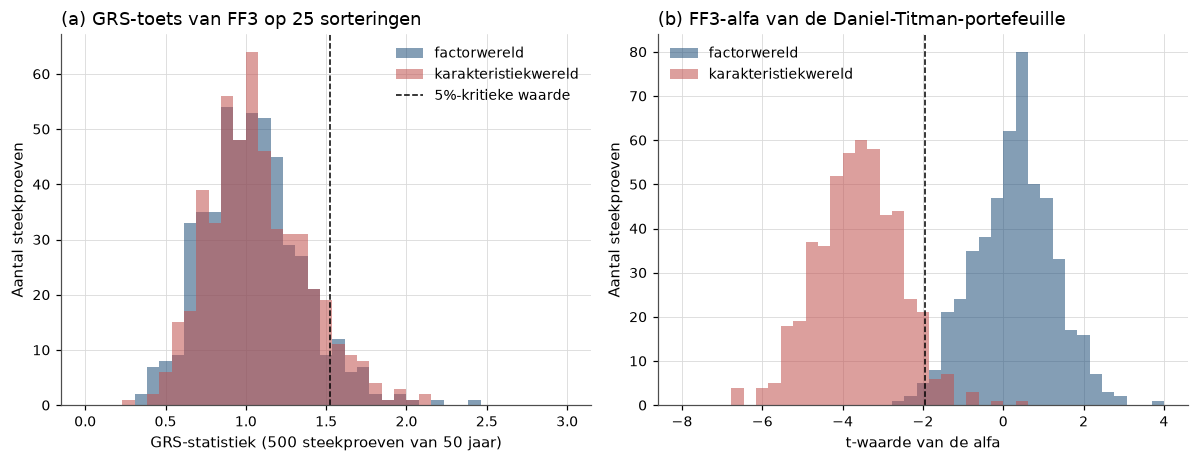

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
bins = np.linspace(0, 3, 40)
for world, color in zip(expected, hap.plotting.COLORS):
    subset = sim_a[sim_a["wereld"] == world]
    axes[0].hist(subset["GRS FF3"], bins=bins, alpha=0.55, color=color, label=world)
    axes[1].hist(subset["t DT"], bins=np.linspace(-8, 4, 40), alpha=0.55, color=color, label=world)
axes[0].axvline(stats.f.ppf(0.95, 25, n_months - 28), color="black", lw=1, ls="--",
                label="5%-kritieke waarde")
axes[0].set_title("(a) GRS-toets van FF3 op 25 sorteringen")
axes[0].set_xlabel("GRS-statistiek (500 steekproeven van 50 jaar)")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend()
axes[1].axvline(-1.96, color="black", lw=1, ls="--")
axes[1].set_title("(b) FF3-alfa van de Daniel-Titman-portefeuille")
axes[1].set_xlabel("t-waarde van de alfa")
axes[1].set_ylabel("Aantal steekproeven")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-fama-french-sim-dt
:label: fig-fama-french-sim-dt
:width: 100%

Links: de GRS-statistiek van het driefactormodel op 25 karakteristiek-gesorteerde
portefeuilles heeft in beide werelden vrijwel dezelfde verdeling. Rechts: de
Daniel-Titman-portefeuille, die binnen de vakjes op geschatte lading sorteert, heeft in de
factorwereld een alfa rond nul en in de karakteristiekwereld een duidelijk negatieve, zoals
{prf:ref}`prop-fama-french-karakteristiek` voorspelt.
:::

In beide werelden verwerpt GRS het CAPM in 38% van de steekproeven, bij een gemiddelde
absolute CAPM-alfa van 0,19% per maand: motief 1 in de cross-sectie, want een prijsfout van
ruim 2% per jaar blijft na vijftig jaar in bijna twee op de drie steekproeven onder de
drempel. Het driefactormodel laat in beide werelden 0,05% per maand over en wordt in 6,8% en
8,8% van de steekproeven verworpen, iets boven de nominale 5% omdat SMB en HML uit eindig
veel aandelen bestaan. De toets doet wat hij moet doen, en kan precies daarom de werelden
niet scheiden. De Daniel-Titman-portefeuille wel: haar gemiddelde alfa is 0,01% (gemiddelde
$t$-waarde 0,29) in de factorwereld en $-0{,}11\%$ (gemiddelde $t$-waarde $-3{,}6$, onder
$-1{,}96$ in 95% van de steekproeven) in de karakteristiekwereld, tegen $-0{,}12\%$ volgens
[](#eq-fama-french-dt-alfa) ([](#ex-fama-french-1)). Die kracht komt uit de opzet: veel
spreiding in ladingen binnen elk vakje, en ladingen die in de tijd niet veranderen. In echte
data is dat anders, en daarover ging het debat tussen {cite:t}`DanielTitman1997` en
{cite:t}`DavisFamaFrench2000`.

### (b) Willekeurige factoren en de cross-sectionele $R^2$

Nu {prf:ref}`prop-fama-french-mechanisch` in een steekproef. We nemen één steekproef van
vijftig jaar uit de factorwereld en vervangen SMB en HML door twee *nepfactoren*: elk een
willekeurige combinatie van SMB en HML met correlatie tussen 0,05 en 0,6, aangevuld met
onafhankelijke ruis. Voor 1000 nepmodellen (steeds met de markt erbij) schatten we de
cross-sectionele OLS-$R^2$ met vrij intercept, en de GRS-toets, die de premies vastlegt op
de gemiddelden van de factoren.

In [6]:
sample_b = simulate_portfolios("factorwereld")
test_b = pd.DataFrame(sample_b[:, :25], columns=test_names)


def cross_sectional_r2(factors):
    """Full-sample betas, then OLS of mean returns on [1, betas]: R^2 and the estimated premia."""
    X = np.column_stack([np.ones(len(factors)), factors])
    betas = np.linalg.lstsq(X, test_b.to_numpy(), rcond=None)[0][1:].T
    Z = np.column_stack([np.ones(25), betas])
    means = test_b.mean().to_numpy()
    coef = np.linalg.lstsq(Z, means, rcond=None)[0]
    return 1 - (means - Z @ coef).var() / means.var(), coef[1:]


true_factors = sample_b[:, 25:28]
r2_true, premia_true = cross_sectional_r2(true_factors)
standardised = (sample_b[:, 26:28] - sample_b[:, 26:28].mean(axis=0)) / sample_b[:, 26:28].std(axis=0)

fakes = []
for _ in range(1000):
    c = rng.uniform(0.05, 0.6)
    base = standardised @ rng.standard_normal((2, 2)).T
    base /= base.std(axis=0)
    fake = 0.02 * (c * base + np.sqrt(1 - c**2) * rng.standard_normal((n_months, 2)))
    factors_fake = np.column_stack([true_factors[:, 0], fake])
    r2, premia = cross_sectional_r2(factors_fake)
    grs = hap.stats.grs_test(test_b, pd.DataFrame(factors_fake, columns=["Mkt", "nep1", "nep2"]))
    fakes.append({"correlatie": c, "R2": r2, "p GRS": grs["pvalue"],
                  "premie / gemiddelde": np.median(np.abs(premia[1:] / fake.mean(axis=0)))})
fakes = pd.DataFrame(fakes)

grs_true = hap.stats.grs_test(test_b, pd.DataFrame(true_factors, columns=factor_names))
pd.DataFrame(
    {"ware factoren": [r2_true, np.nan, np.nan, grs_true["pvalue"], float(grs_true["pvalue"] < 0.05)],
     "nepfactoren (mediaan)": [fakes["R2"].median(), (fakes["R2"] > 0.8).mean(),
                               fakes["premie / gemiddelde"].median(), fakes["p GRS"].median(),
                               (fakes["p GRS"] < 0.05).mean()]},
    index=["cross-sectionele R2", "fractie R2 > 0,8", "|premie| / |gemiddelde factor|", "p-waarde GRS",
           "fractie verworpen door GRS (5%)"],
).round(4)

,ware factoren,nepfactoren (mediaan)
cross-sectionele R2,0.8641,0.8335
"fractie R2 > 0,8",NaN,0.6650
|premie| / |gemiddelde factor|,NaN,15.7787
p-waarde GRS,0.1212,0.0200
fractie verworpen door GRS (5%),0.0000,0.9780


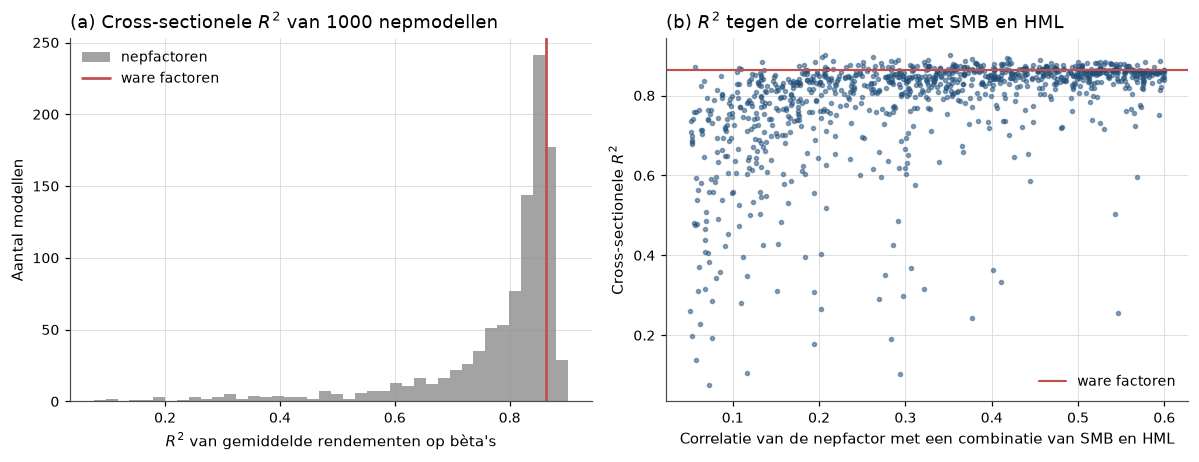

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].hist(fakes["R2"], bins=40, color=hap.plotting.COLORS[7], alpha=0.8, label="nepfactoren")
axes[0].axvline(r2_true, color=hap.plotting.COLORS[1], lw=1.8, label="ware factoren")
axes[0].set_title("(a) Cross-sectionele $R^2$ van 1000 nepmodellen")
axes[0].set_xlabel("$R^2$ van gemiddelde rendementen op bèta's")
axes[0].set_ylabel("Aantal modellen")
axes[0].legend(loc="upper left")
axes[1].scatter(fakes["correlatie"], fakes["R2"], s=7, alpha=0.5, color=hap.plotting.COLORS[0])
axes[1].axhline(r2_true, color=hap.plotting.COLORS[1], lw=1.4, label="ware factoren")
axes[1].set_title("(b) $R^2$ tegen de correlatie met SMB en HML")
axes[1].set_xlabel("Correlatie van de nepfactor met een combinatie van SMB en HML")
axes[1].set_ylabel("Cross-sectionele $R^2$")
axes[1].legend(loc="lower right")
fig.tight_layout()
plt.show()

:::{figure} #cel-fama-french-sim-lns
:label: fig-fama-french-sim-lns
:width: 100%

Links: factoren die grotendeels ruis zijn, geven op 25 portefeuilles met een sterke
factorstructuur een cross-sectionele $R^2$ die vaak weinig onderdoet voor die van de ware
factoren. Rechts: de $R^2$ stijgt met de correlatie, maar is ook bij lage correlatie vaak
hoog. De GRS-toets, die de premies vastlegt, verwerpt vrijwel alle nepmodellen.
:::

Met de ware factoren is de cross-sectionele $R^2$ 0,86 en verwerpt GRS niet
($p = 0{,}12$). De nepfactoren halen een mediane $R^2$ van 0,83, twee derde van hen komt
boven 0,8, hun geschatte premies zijn in de mediaan 16 keer hun gemiddelde rendement, en GRS
verwerpt 98% van hen. De $R^2$ meet hoe goed de bèta's de *richtingen* van de 25
portefeuilles volgen, niet of de premies kloppen: Rolls tautologie uit [](#03-14-roll) in
meer dimensies.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Eugene F. Fama en Kenneth R. French, *Common Risk Factors in the Returns on
Stocks and Bonds*, Journal of Financial Economics 1993 {cite}`FamaFrench1993`; Fama en
French, *The Cross-Section of Expected Stock Returns*, Journal of Finance 1992
{cite}`FamaFrench1992`; en de langere steekproef van {cite:t}`DavisFamaFrench2000`.

**Wat.** (1) Fama en French (1993), tabel 9a, regressies (ii) en (iv), juli 1963 tot
december 1991 (342 maanden): de intercepten van de 25 size/BM-portefeuilles op de markt en
op de drie factoren. Op de drie factoren is klein-groei $-0{,}34\%$ per maand
($t = -3{,}16$) en groot-groei $0{,}21\%$ ($t = 3{,}27$); drie van de 25 intercepten wijken
meer dan 0,2% van nul af en 16 liggen binnen 0,1%. De $R^2$'s liggen volgens hun tabel 6 in
de kleinste size-groep tussen 0,94 en 0,97, met een laagste waarde van 0,83 voor
groot-hoog. Tabel 9c: GRS op 25 aandelen- en zeven obligatieportefeuilles is 1,56 voor de
drie aandelenfactoren (kansniveau 0,961) en 1,91 voor de markt alleen (0,996). (2) Fama en
French (1992), tabel III (zie de theorie). (3) Davis, Fama en French: de waardepremie is over
1929–1963 even sterk als daarna.

**Data hier.** Kenneth French Data Library via `hap.data.french`: de factoren
(`"F-F_Research_Data_Factors"`) vanaf 1926-07, de 25 waardegewogen
size/BM-portefeuilles (`"25_Portfolios_5x5"`) en de 100 waardegewogen
size/BM-portefeuilles (`"100_Portfolios_10x10"`) met hun gemiddelde marktwaarde
(tabel 5) en waardegewogen gemiddelde B/M (tabel 6), vanaf 1963-07, tot 2026-07.

**Verschil met het origineel.** (1) French heeft de data sinds 1993 herzien (boekwaarde,
delistings, uitbreiding van Compustat), dus ook de overlappende jaren wijken af; wij toetsen
GRS op de 25 aandelenportefeuilles, niet op 32. (2) Fama en French (1992) gebruikten
individuele aandelen met bèta's van size-bèta-portefeuilles; wij draaien Fama-MacBeth op de
100 size/BM-portefeuilles met bèta's over de hele periode en de log van hun gemiddelde
marktwaarde en B/M, een maand vertraagd. Dat is een **benadering met portefeuilles**: bèta
varieert nauwelijks binnen een size-groep, precies de variatie waarop Fama en French hun
toets bouwden. (3) "Na publicatie" begint in 1993-01.

**Verwachte afwijking.** (1) Op 1963–1991 liggen de alfa's gemiddeld binnen 0,05% per
maand van tabel 9a, met hetzelfde teken in de hoeken (klein-groei significant negatief,
groot-groei positief); de gemiddelde absolute FF3-alfa is minder dan de helft van die van
het CAPM en de gemiddelde FF3-$R^2$ ligt boven 0,9; over de volledige periode verwerpt GRS
het driefactormodel. (2) Met size en B/M erin is bèta insignificant, B/M significant
positief en size negatief, maar zwakker dan de $t = -1{,}99$ op aandelen. (3) HML is vóór
1963 positief; SMB is na 1993 niet van nul te onderscheiden.
```

In [8]:
ff = hap_data.french("F-F_Research_Data_Factors")
rf, factors = ff["RF"], ff[["Mkt-RF", "SMB", "HML"]]
ff25 = hap_data.french("25_Portfolios_5x5").sub(rf, axis=0).loc["1963-07":].dropna()

size_labels, bm_labels = ["Klein", "2", "3", "4", "Groot"], ["Laag", "2", "3", "4", "Hoog"]
models = {"CAPM": ["Mkt-RF"], "FF3": ["Mkt-RF", "SMB", "HML"]}
periods = {"1963-07 t/m 1991-12 (FF 1993)": ("1963-07", "1991-12"),
           "1963-07 t/m 2026-07": ("1963-07", "2026-07"),
           "1993-01 t/m 2026-07 (na publicatie)": ("1993-01", "2026-07")}


def model_summary(start, end, model):
    """Time-series fit of the 25 portfolios on one model: alphas, t-values, R^2 and GRS."""
    Y, F = ff25.loc[start:end], factors.loc[start:end, models[model]]
    alpha, t, r2 = ts_regression(Y.to_numpy(), F.to_numpy())
    grs = hap.stats.grs_test(Y, F)
    return alpha, t, r2, grs


rows = {}
for label, (start, end) in periods.items():
    for model in models:
        alpha, t, r2, grs = model_summary(start, end, model)
        rows[(label, model)] = {
            "maanden": len(ff25.loc[start:end]), "gem. |alfa| (% p.m.)": 100 * np.abs(alpha).mean(),
            "gem. R2": r2.mean(), "GRS": grs["grs"], "p GRS": grs["pvalue"],
            "alfa klein-groei": 100 * alpha[0], "t klein-groei": t[0],
            "alfa groot-groei": 100 * alpha[20], "t groot-groei": t[20]}
pd.DataFrame(rows).T.round(3)

maanden  gem. |alfa| (% p.m.)  \
1963-07 t/m 1991-12 (FF 1993)       CAPM    342.0                 0.257   
                                    FF3     342.0                 0.094   
1963-07 t/m 2026-07                 CAPM    757.0                 0.198   
                                    FF3     757.0                 0.087   
1993-01 t/m 2026-07 (na publicatie) CAPM    403.0                 0.157   
                                    FF3     403.0                 0.116   

                                          gem. R2    GRS  p GRS  \
1963-07 t/m 1991-12 (FF 1993)       CAPM    0.794  1.985  0.004   
                                    FF3     0.934  1.432  0.086   
1963-07 t/m 2026-07                 CAPM    0.734  4.196  0.000   
                                    FF3     0.910  3.629  0.000   
1993-01 t/m 2026-07 (na publicatie) CAPM    0.692  3.623  0.000   
                                    FF3     0.895  3.534  0.000   

                                          alfa klein-groei  t klein-groei  \
1963-07 t/m 1991-12 (FF 1993)       CAPM            -0.265         -1.141   
                                    FF3             -0.368         -3.428   
1963-07 t/m 2026-07                 CAPM            -0.527         -2.961   
                                    FF3             -0.468         -5.093   
1993-01 t/m 2026-07 (na publicatie) CAPM            -0.735         -2.763   
                                    FF3             -0.544         -3.747   

                                          alfa groot-groei  t groot-groei  
1963-07 t/m 1991-12 (FF 1993)       CAPM            -0.043         -0.468  
                                    FF3              0.193          2.861  
1963-07 t/m 2026-07                 CAPM             0.018          0.311  
                                    FF3              0.162          4.022  
1993-01 t/m 2026-07 (na publicatie) CAPM             0.095          1.231  
                                    FF3              0.154          3.204

Op de steekproef van Fama en French daalt de gemiddelde absolute alfa van 0,26% per maand
(CAPM) naar 0,09% (FF3) en stijgt de gemiddelde $R^2$ van 0,79 naar 0,93. GRS daalt van 1,99
($p = 0{,}004$) naar 1,43 ($p = 0{,}086$): op de 25 aandelenportefeuilles alleen wordt het
driefactormodel in deze periode niet verworpen, terwijl Fama en French het met de
obligaties erbij op kansniveau 0,961 net verwierpen. Tot 2026 blijft de gemiddelde absolute
alfa laag (0,09% tegen 0,20%), maar GRS verwerpt met 3,63 ($p < 0{,}001$) en klein-groei
heeft een alfa van $-0{,}47\%$ ($t = -5{,}09$): de standaardfout krimpt met de wortel van de
steekproef, en een fout die in 1993 net zichtbaar was, is nu onmiskenbaar. Na publicatie is
de winst ten opzichte van het CAPM kleiner (0,12% tegen 0,16%), en klein-groei doet het
slechter dan ooit ($-0{,}54\%$, $t = -3{,}75$).

In [9]:
published = {
    "CAPM gepubliceerd": [[-0.22, 0.15, 0.30, 0.42, 0.54], [-0.18, 0.17, 0.36, 0.39, 0.53],
                          [-0.16, 0.15, 0.23, 0.39, 0.50], [-0.05, -0.14, 0.12, 0.35, 0.57],
                          [-0.04, -0.07, -0.07, 0.20, 0.21]],
    "FF3 gepubliceerd": [[-0.34, -0.12, -0.05, 0.01, 0.00], [-0.11, -0.01, 0.08, 0.03, 0.02],
                         [-0.11, 0.04, -0.04, 0.05, 0.05], [0.09, -0.22, -0.08, 0.03, 0.13],
                         [0.21, -0.05, -0.13, -0.05, -0.16]],
}
ff_sample = {model: model_summary("1963-07", "1991-12", model) for model in models}


def grid(values):
    return pd.DataFrame(np.asarray(values).reshape(5, 5), index=size_labels, columns=bm_labels)


table_9a = {
    "CAPM alfa (% p.m.)": grid(100 * ff_sample["CAPM"][0]),
    "CAPM gepubliceerd": grid(published["CAPM gepubliceerd"]),
    "FF3 alfa (% p.m.)": grid(100 * ff_sample["FF3"][0]),
    "FF3 gepubliceerd": grid(published["FF3 gepubliceerd"]),
    "FF3 t(alfa)": grid(ff_sample["FF3"][1]),
    "FF3 R2": grid(ff_sample["FF3"][2]),
}
diff_capm = (table_9a["CAPM alfa (% p.m.)"] - table_9a["CAPM gepubliceerd"]).abs()
diff_ff3 = (table_9a["FF3 alfa (% p.m.)"] - table_9a["FF3 gepubliceerd"]).abs()
print(f"gemiddeld |verschil| met tabel 9a: CAPM {diff_capm.to_numpy().mean():.3f}, "
      f"FF3 {diff_ff3.to_numpy().mean():.3f} procentpunt per maand; "
      f"maximaal {max(diff_capm.to_numpy().max(), diff_ff3.to_numpy().max()):.3f}")
pd.concat(table_9a, names=["grootheid", "size"]).round(2)

gemiddeld |verschil| met tabel 9a: CAPM 0.033, FF3 0.045 procentpunt per maand; maximaal 0.130


Laag     2     3     4  Hoog
grootheid          size                               
CAPM alfa (% p.m.) Klein -0.26  0.15  0.27  0.42  0.54
                   2     -0.19  0.14  0.38  0.48  0.52
                   3     -0.12  0.17  0.25  0.42  0.48
                   4     -0.04 -0.10  0.19  0.39  0.44
                   Groot -0.04 -0.07 -0.00  0.16  0.17
CAPM gepubliceerd  Klein -0.22  0.15  0.30  0.42  0.54
                   2     -0.18  0.17  0.36  0.39  0.53
                   3     -0.16  0.15  0.23  0.39  0.50
                   4     -0.05 -0.14  0.12  0.35  0.57
                   Groot -0.04 -0.07 -0.07  0.20  0.21
FF3 alfa (% p.m.)  Klein -0.37 -0.10 -0.05  0.06  0.06
                   2     -0.14 -0.03  0.13  0.14  0.06
                   3     -0.04  0.05  0.02  0.12  0.06
                   4      0.12 -0.15  0.00  0.10  0.04
                   Groot  0.19 -0.03 -0.05 -0.06 -0.17
FF3 gepubliceerd   Klein -0.34 -0.12 -0.05  0.01  0.00
                   2     -0.11 -0.01  0.08  0.03  0.02
                   3     -0.11  0.04 -0.04  0.05  0.05
                   4      0.09 -0.22 -0.08  0.03  0.13
                   Groot  0.21 -0.05 -0.13 -0.05 -0.16
FF3 t(alfa)        Klein -3.43 -1.23 -0.75  1.01  0.88
                   2     -1.66 -0.45  1.95  2.30  0.95
                   3     -0.49  0.73  0.29  1.77  0.66
                   4      1.54 -1.85  0.06  1.18  0.37
                   Groot  2.86 -0.40 -0.58 -0.83 -1.60
FF3 R2             Klein  0.94  0.96  0.96  0.97  0.96
                   2      0.96  0.96  0.96  0.96  0.96
                   3      0.96  0.95  0.94  0.94  0.93
                   4      0.95  0.92  0.92  0.91  0.90
                   Groot  0.94  0.92  0.86  0.90  0.84

De gepubliceerde waarden lazen we uit een scan van tabel 9a; ze kloppen met de uitspraken
in de tekst van Fama en French (drie FF3-intercepten verder dan 0,2% en zestien binnen 0,1%
van nul). Onze alfa's wijken gemiddeld 0,03 (CAPM) en 0,05 (FF3) procentpunt per maand af,
maximaal 0,13. De rangorde is bewaard: bij het CAPM stijgen de alfa's in elke size-groep van
de laagste naar de hoogste B/M-kolom, en bij het driefactormodel zitten de grootste fouten
in de groeikolom, negatief bij klein ($-0{,}37\%$, $t = -3{,}43$) en positief bij groot
(0,19%, $t = 2{,}86$). De $R^2$ van de kleinste size-groep ligt tussen 0,94 en 0,97; de
laagste is 0,84, voor groot-hoog.

Nu de benadering van tabel III. De 100 portefeuilles hebben een gemiddelde marktwaarde
en een gemiddelde B/M die elke maand bekend zijn; we vertragen beide een maand.

In [10]:
p100 = hap_data.french("100_Portfolios_10x10").sub(rf, axis=0).loc["1963-07":]
avg_me = hap_data.french("100_Portfolios_10x10", table=5)
avg_bm = hap_data.french("100_Portfolios_10x10", table=6, percent=False)
log_me = np.log(avg_me.where(avg_me > 0)).shift(1)
log_bm = np.log(avg_bm.where(avg_bm > 0)).shift(1)
specs = [["bèta"], ["log ME"], ["log B/M"], ["bèta", "log ME"], ["log ME", "log B/M"],
         ["bèta", "log ME", "log B/M"]]


def fama_macbeth_fast(returns, chars_fm):
    """Fama-MacBeth with lags=0 (as hap.stats.fama_macbeth), one numpy least squares per month."""
    # TODO: naar hap.stats (hap.stats.fama_macbeth kost hier ruim 5 s per specificatie)
    names, Y = list(chars_fm), returns.to_numpy()
    panels = [np.broadcast_to(c.reindex(columns=returns.columns).to_numpy(), Y.shape) if len(c) == 1
              else c.reindex(index=returns.index, columns=returns.columns).to_numpy()
              for c in chars_fm.values()]
    gammas = []
    for t in range(len(Y)):
        X = np.column_stack([np.ones(Y.shape[1])] + [panel[t] for panel in panels])
        ok = np.isfinite(Y[t]) & np.isfinite(X).all(axis=1)
        if ok.sum() > len(names):
            gammas.append(np.linalg.lstsq(X[ok], Y[t, ok], rcond=None)[0])
    gammas = np.array(gammas)
    estimate = gammas.mean(axis=0)
    tstat = estimate / (gammas.std(axis=0) / np.sqrt(len(gammas)))   # divisor T, as the HAC estimator in hap
    return pd.DataFrame({"estimate": estimate, "tstat": tstat}, index=["const", *names])


def fama_macbeth_table(start, end):
    """Fama-MacBeth on the 100 size/BM portfolios with full-period betas and lagged characteristics."""
    R = p100.loc[start:end]
    f = factors["Mkt-RF"].loc[R.index]
    chars_fm = {"bèta": (R.apply(lambda col: col.cov(f)) / f.var()).to_frame().T,
                "log ME": log_me.loc[start:end], "log B/M": log_bm.loc[start:end]}
    rows = {}
    for spec in specs:
        out = fama_macbeth_fast(R, {k: chars_fm[k] for k in spec})
        rows[" + ".join(spec)] = {**{(k, "coëf. (%)"): 100 * out.loc[k, "estimate"] for k in spec},
                                  **{(k, "t"): out.loc[k, "tstat"] for k in spec}}
    columns = [(k, s) for k in ["bèta", "log ME", "log B/M"] for s in ["coëf. (%)", "t"]]
    return pd.DataFrame(rows).T.reindex(columns=pd.MultiIndex.from_tuples(columns))


pd.concat({"1963-07 t/m 1990-12": fama_macbeth_table("1963-07", "1990-12"),
           "1963-07 t/m 2026-07": fama_macbeth_table("1963-07", "2026-07")}).round(2)

bèta          log ME        \
                                            coëf. (%)     t coëf. (%)     t   
1963-07 t/m 1990-12 bèta                        -0.37 -0.80       NaN   NaN   
                    log ME                        NaN   NaN     -0.07 -1.43   
                    log B/M                       NaN   NaN       NaN   NaN   
                    bèta + log ME               -1.08 -2.49     -0.13 -2.83   
                    log ME + log B/M              NaN   NaN     -0.07 -1.38   
                    bèta + log ME + log B/M     -0.11 -0.30     -0.07 -1.73   
1963-07 t/m 2026-07 bèta                        -0.35 -0.96       NaN   NaN   
                    log ME                        NaN   NaN     -0.04 -1.26   
                    log B/M                       NaN   NaN       NaN   NaN   
                    bèta + log ME               -0.78 -2.45     -0.07 -2.78   
                    log ME + log B/M              NaN   NaN     -0.04 -1.17   
                    bèta + log ME + log B/M     -0.22 -0.82     -0.05 -1.71   

                                              log B/M        
                                            coëf. (%)     t  
1963-07 t/m 1990-12 bèta                          NaN   NaN  
                    log ME                        NaN   NaN  
                    log B/M                      0.26  2.86  
                    bèta + log ME                 NaN   NaN  
                    log ME + log B/M             0.25  2.76  
                    bèta + log ME + log B/M      0.24  2.74  
1963-07 t/m 2026-07 bèta                          NaN   NaN  
                    log ME                        NaN   NaN  
                    log B/M                      0.18  2.92  
                    bèta + log ME                 NaN   NaN  
                    log ME + log B/M             0.17  2.72  
                    bèta + log ME + log B/M      0.15  2.43

Over 1963–1990 is de helling op bèta alleen $-0{,}37\%$ per maand ($t = -0{,}80$),
insignificant zoals hun 0,15% ($t = 0{,}46$). B/M alleen geeft 0,26% ($t = 2{,}86$) tegen hun
0,50% ($t = 5{,}71$). Met alle drie is de bèta-helling $-0{,}11\%$ ($t = -0{,}30$), de
size-helling $-0{,}07\%$ ($t = -1{,}73$) en de B/M-helling 0,24% ($t = 2{,}74$): de tekens
van tabel III, en bèta insignificant zodra size en B/M erin zitten. De hellingen zijn
kleiner omdat honderd portefeuilles de extremen wegmiddelen. Met alleen bèta en size wordt
bèta significant *negatief* ($-1{,}08\%$, $t = -2{,}49$); dat is een ontwerpprobleem, geen
negatieve beloning: in op size gesorteerde portefeuilles zijn bèta en size sterk
gecorreleerd, en daarom sorteerden Fama en French op bèta binnen size-groepen. Tot 2026
blijft het patroon staan, met een zwakkere B/M-helling (0,15%, $t = 2{,}43$).

Tot slot het verloop van SMB en HML zelf: per decennium, en in drie periodes rond de
steekproef van Fama en French. Hier komt motief 1 terug. Een factorpremie van 0,3% per
maand met een volatiliteit van 3% heeft over tien jaar een standaardfout van
$3/\sqrt{120} \approx 0{,}27\%$: één decennium zegt vrijwel niets.

In [11]:
def premium_row(frame):
    """Mean, standard error and t of SMB and HML (% per month)."""
    n = len(frame)
    out = {"maanden": n}
    for name in ["SMB", "HML"]:
        s = frame[name]
        out |= {f"{name} gem.": 100 * s.mean(), f"{name} SE": 100 * s.std() / np.sqrt(n),
                f"{name} t": s.mean() / (s.std() / np.sqrt(n))}
    return out


decades = {f"{d}-{min(d + 9, factors.index.year.max())}": premium_row(g)
           for d, g in factors.groupby((factors.index.year // 10) * 10)}
spans = {"1926-07 t/m 1963-06 (vóór FF)": ("1926-07", "1963-06"),
         "1963-07 t/m 1991-12 (FF 1993)": ("1963-07", "1991-12"),
         "1993-01 t/m 2026-07 (na publicatie)": ("1993-01", "2026-07")}
decade_table = pd.DataFrame(decades).T
span_table = pd.DataFrame({k: premium_row(factors.loc[a:b]) for k, (a, b) in spans.items()}).T
pd.concat({"per decennium": decade_table, "per periode": span_table}).round(3)

maanden  SMB gem.  SMB SE  \
per decennium 1920-1929                               42.0    -1.045   0.427   
              1930-1939                              120.0     0.835   0.494   
              1940-1949                              120.0     0.397   0.212   
              1950-1959                              120.0    -0.061   0.141   
              1960-1969                              120.0     0.401   0.233   
              1970-1979                              120.0     0.289   0.310   
              1980-1989                              120.0    -0.005   0.215   
              1990-1999                              120.0    -0.129   0.270   
              2000-2009                              120.0     0.420   0.361   
              2010-2019                              120.0    -0.017   0.203   
              2020-2026                               79.0    -0.163   0.331   
per periode   1926-07 t/m 1963-06 (vóór FF)          444.0     0.197   0.160   
              1963-07 t/m 1991-12 (FF 1993)          342.0     0.259   0.155   
              1993-01 t/m 2026-07 (na publicatie)    403.0     0.039   0.156   

                                                   SMB t  HML gem.  HML SE  \
per decennium 1920-1929                           -2.447     0.233   0.398   
              1930-1939                            1.689     0.332   0.678   
              1940-1949                            1.874     0.798   0.243   
              1950-1959                           -0.429     0.297   0.207   
              1960-1969                            1.723     0.283   0.174   
              1970-1979                            0.930     0.654   0.250   
              1980-1989                           -0.021     0.492   0.253   
              1990-1999                           -0.477     0.004   0.238   
              2000-2009                            1.162     0.662   0.337   
              2010-2019                           -0.083    -0.196   0.208   
              2020-2026                           -0.490     0.220   0.487   
per periode   1926-07 t/m 1963-06 (vóór FF)        1.235     0.450   0.208   
              1963-07 t/m 1991-12 (FF 1993)        1.674     0.378   0.137   
              1993-01 t/m 2026-07 (na publicatie)  0.251     0.190   0.164   

                                                   HML t  
per decennium 1920-1929                            0.585  
              1930-1939                            0.489  
              1940-1949                            3.287  
              1950-1959                            1.439  
              1960-1969                            1.628  
              1970-1979                            2.617  
              1980-1989                            1.945  
              1990-1999                            0.018  
              2000-2009                            1.968  
              2010-2019                           -0.941  
              2020-2026                            0.451  
per periode   1926-07 t/m 1963-06 (vóór FF)        2.170  
              1963-07 t/m 1991-12 (FF 1993)        2.750  
              1993-01 t/m 2026-07 (na publicatie)  1.159

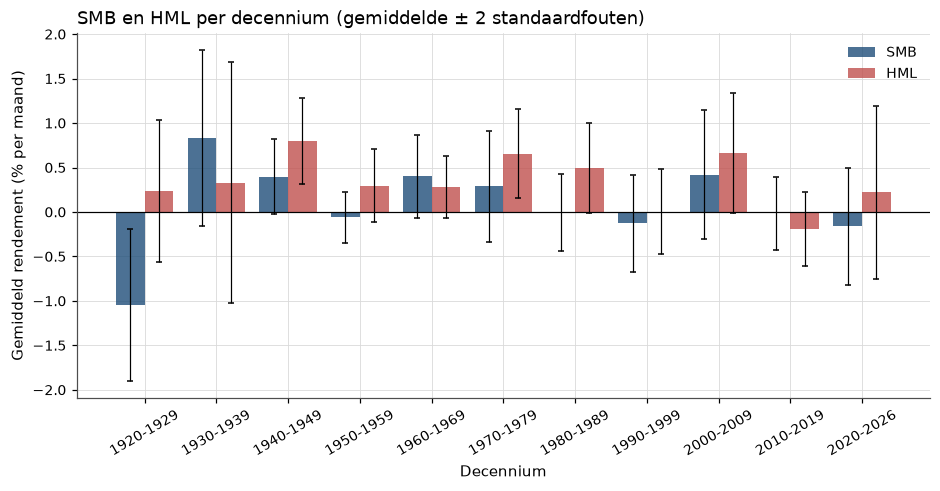

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.3))
x = np.arange(len(decade_table))
for offset, name, color in [(-0.2, "SMB", hap.plotting.COLORS[0]), (0.2, "HML", hap.plotting.COLORS[1])]:
    ax.bar(x + offset, decade_table[f"{name} gem."], width=0.4, color=color, alpha=0.8, label=name)
    ax.errorbar(x + offset, decade_table[f"{name} gem."], yerr=2 * decade_table[f"{name} SE"],
                fmt="none", ecolor="black", capsize=2, lw=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x, decade_table.index, rotation=30)
ax.set_title("SMB en HML per decennium (gemiddelde ± 2 standaardfouten)")
ax.set_xlabel("Decennium")
ax.set_ylabel("Gemiddeld rendement (% per maand)")
ax.legend()
plt.show()

:::{figure} #cel-fama-french-decennia
:label: fig-fama-french-decennia
:width: 100%

Gemiddelde maandrendementen van SMB en HML per decennium, met twee standaardfouten. De
meeste foutbalken bevatten nul. HML is in elk decennium tot en met de jaren tachtig positief,
ook vóór de steekproef van Fama en French, en in de jaren 2010 negatief; SMB wisselt van
teken, met de jaren dertig als sterkste decennium.
:::

Over 1926–1963 is HML 0,45% per maand ($t = 2{,}17$) en SMB 0,20% ($t = 1{,}24$): de
waardepremie bestond voordat iemand ernaar zocht, zoals {cite:t}`DavisFamaFrench2000`
rapporteerden. In de steekproef van Fama en French is HML 0,38% ($t = 2{,}75$) en SMB 0,26%
($t = 1{,}67$). Na publicatie is SMB 0,04% ($t = 0{,}25$) en HML 0,19% ($t = 1{,}16$). Of dat
een verdwijnende premie is of een slechte reeks trekkingen, kan geen $t$-toets over twintig
jaar zeggen.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Veel, met drie getallen per aandeel. Op de 25 portefeuilles
brengt het de gemiddelde absolute prijsfout terug van een kwart procent per maand naar
minder dan een tiende, en stijgt de verklaarde variantie van ongeveer 80 naar meer dan 90%.
Het vangt de E/P-, kasstroom- en lange-termijn-reversal-anomalieën op
{cite}`FamaFrench1996`, de waardepremie die het beprijst, bestond al in 1926, en "alfa na
correctie voor size en value" werd de standaard voor fondsbeoordeling en de kostenvoet van
vermogen. Als de wereld een factorstructuur heeft, doet de tijdreekstoets precies wat
{prf:ref}`thm-fama-french-sdf` belooft.

**Waar het breekt.** Klein-groei: een alfa van $-0{,}47\%$ per maand ($t = -5{,}09$) over
1963–2026, en GRS verwerpt het model met $F = 3{,}63$. Momentum, de anomalie die Fama en
French in 1996 niet konden verklaren ([](#ex-fama-french-3)). En de premies zelf: SMB is
sinds publicatie niet van nul te onderscheiden (0,04% per maand, $t = 0{,}25$). Daaronder
ligt de methodologische barst uit de simulatie: op 25 sorteringen is een kleine alfa deels
constructie, en zwak gecorreleerde factoren geven een bijna even goede cross-sectionele fit.

**Risico of vergissing?** Santa-Clara noemt het het joint-hypothesis-probleem opnieuw,
nooit beslecht {cite}`SantaClara2026`. De Chicago-lezing: SMB en HML bootsen financiële nood
na; kleine en waardeaandelen zijn marginale bedrijven met veel schuld en zwakke winsten, die
slecht presteren als het economisch slecht gaat {cite}`ChanChen1991,FamaFrench1995`. De
Yale-lezing: beleggers extrapoleren groei, betalen te veel voor glamour en te weinig voor
waarde, en de premie is de langzame correctie {cite}`LakonishokShleiferVishny1994`. Wat de
kampen zou scheiden, is een premie die de covariantie volgt en niet het kenmerk. Daniel en
Titman meenden die te vinden, Davis, Fama en French vonden het tegendeel, en
{prf:ref}`prop-fama-french-karakteristiek` laat zien waarom de toets zwak is zolang lading
en kenmerk sterk correleren. Het verdwijnen van SMB na publicatie past bij datamining
{cite}`Black1993` of arbitrage; HML vóór 1963 bij een echte premie. Voor een belegger is het
de vraag van Santa-Clara: wie in 1993 een waardefonds kocht, droeg die een beprijsd risico of
dacht die iets te weten wat de prijs niet wist? Dezelfde portefeuille kan beide zijn geweest.

**Wat er daarna kwam.** De voortzetting van rendementen over het afgelopen jaar, die het
driefactormodel niet kon opvangen, werd een factor op zichzelf: [](#04-19-momentum).

## Oefeningen

:::{exercise}
:label: ex-fama-french-1

**De alfa van een karakteristiek-gebalanceerde portefeuille.** Gebruik
[](#eq-fama-french-dt) met twee kenmerken en de simulatie van deel (a).

1. Laat zien dat {prf:ref}`prop-fama-french-karakteristiek` met twee factoren en
   factorportefeuilles $\mathbf{H}$ (SMB en HML) wordt:
   $\boldsymbol{\alpha}_w^{\text{karakteristiek}} = -\boldsymbol{\lambda}'\left(\boldsymbol{\ell}_w - \rho\,\mathbf{z}_w\right)$,
   als de ladingen van $\mathbf{H}$ gelijk zijn aan $\rho$ maal hun kenmerken.
2. Bereken met `exposures`, `W` en `chars` de voorspelde alfa van de
   Daniel-Titman-portefeuille en vergelijk met de simulatie.
3. Hoe groot moet $\ell_w - \rho z_w$ zijn voor een verwachte $t$-waarde van $-2$ na
   vijftig jaar?
:::

:::{solution} ex-fama-french-1
:class: dropdown

**(1)** Met goede spreiding is $R^{e}_{w} = \mu_w + \boldsymbol{\ell}_w'\mathbf{f}$ en
$\mathbf{R}_H = \boldsymbol{\mu}_H + \mathbf{L}_H\mathbf{f}$, met $\mathbf{L}_H$ de
$2 \times 2$-matrix van ladingen van SMB en HML. De hellingen zijn
$\mathbf{h}' = \boldsymbol{\ell}_w'\mathbf{L}_H^{-1}$ en de alfa is
$\mu_w - \boldsymbol{\ell}_w'\mathbf{L}_H^{-1}\boldsymbol{\mu}_H$. In de
karakteristiekwereld is $\mu_w = \boldsymbol{\lambda}'\rho\mathbf{z}_w$ en
$\boldsymbol{\mu}_H = \rho\mathbf{Z}_H'\boldsymbol{\lambda}$ met
$\mathbf{L}_H = \rho\mathbf{Z}_H$ (ladingen gelijk aan $\rho$ maal kenmerken), zodat
$\mathbf{L}_H^{-1}\boldsymbol{\mu}_H = \boldsymbol{\lambda}$ en de alfa
$\boldsymbol{\lambda}'(\rho\mathbf{z}_w - \boldsymbol{\ell}_w)$ is. In de factorwereld
is $\boldsymbol{\mu}_H = \mathbf{L}_H\boldsymbol{\lambda}$ en $\mu_w = \boldsymbol{\ell}_w'\boldsymbol{\lambda}$,
dus de alfa is nul.

**(2) en (3)**

In [13]:
dt_loading, dt_char = exposures[28, 1:], W[28] @ chars
H_loadings, H_chars = exposures[26:28, 1:], W[26:28] @ chars
predicted = {
    "voorspeld, ideale factoren": -lam_char @ (dt_loading - rho * dt_char),
    "voorspeld, werkelijke SMB en HML": (expected["karakteristiekwereld"][28]
                                         - dt_loading @ np.linalg.solve(H_loadings.T,
                                                                        expected["karakteristiekwereld"][26:28])),
    "gesimuleerd (gemiddelde)": sim_a.loc[sim_a["wereld"] == "karakteristiekwereld", "alfa DT"].mean(),
}
resid_sd = np.sqrt(noise_root[28] @ noise_root[28])
needed = 2 * resid_sd / np.sqrt(n_months) / lam_char[1]
print(f"residuele volatiliteit DT-portefeuille: {100 * resid_sd:.3f}% per maand")
print(f"benodigde l_w - rho z_w (waarde) voor t = -2: {needed:.3f}; hier: {(dt_loading - rho * dt_char)[1]:.3f}")
(100 * pd.Series(predicted)).round(4)

residuele volatiliteit DT-portefeuille: 0.640% per maand
benodigde l_w - rho z_w (waarde) voor t = -2: 0.261; hier: 0.647


voorspeld, ideale factoren         -0.1216
voorspeld, werkelijke SMB en HML   -0.1177
gesimuleerd (gemiddelde)           -0.1114
dtype: float64

De ideale formule ($-0{,}12\%$) en die met de werkelijke ladingen van SMB en HML liggen
dicht bij de simulatie ($-0{,}11\%$); het restverschil komt doordat SMB en HML uit eindig veel
aandelen bestaan. Het laatste getal laat zien waar de kracht vandaan komt: het deel van de
lading dat het kenmerk niet verklaart, moet groot zijn ten opzichte van de residuele ruis. In
echte data is dat schaars, en daarom kon één tabel het debat tussen Daniel-Titman en
Davis-Fama-French niet beslissen.
:::

:::{exercise}
:label: ex-fama-french-2

**De eerste aanbeveling van Lewellen, Nagel en Shanken.** Neem de 25
size/BM-portefeuilles en de tien industrieportefeuilles van French
(`"10_Industry_Portfolios"`), 1963-07 t/m 2026-07.

1. Bereken voor het CAPM en het driefactormodel de gemiddelde absolute alfa en GRS op de
   tien industrieën.
2. Bereken de cross-sectionele OLS-$R^2$ van het driefactormodel (vrij intercept,
   full-sample bèta's) op de 25 portefeuilles, en op de 25 samen met de industrieën;
   vergelijk de premies met de gemiddelden van de factoren.
3. Wat leert dit over de 25 portefeuilles als toets?
:::

:::{solution} ex-fama-french-2
:class: dropdown

In [14]:
ind10 = hap_data.french("10_Industry_Portfolios").sub(rf, axis=0).loc["1963-07":"2026-07"]
F_all = factors.loc[ind10.index]


def cs_fit(assets):
    """Cross-sectional OLS of mean excess returns on full-sample FF3 betas."""
    X = np.column_stack([np.ones(len(F_all)), F_all.to_numpy()])
    betas = np.linalg.lstsq(X, assets.to_numpy(), rcond=None)[0][1:].T
    Z = np.column_stack([np.ones(assets.shape[1]), betas])
    means = assets.mean().to_numpy()
    coef = np.linalg.lstsq(Z, means, rcond=None)[0]
    return {"R2": 1 - (means - Z @ coef).var() / means.var(), "intercept (%)": 100 * coef[0],
            **{f"premie {k} (%)": 100 * v for k, v in zip(F_all.columns, coef[1:])}}


industries = {m: hap.stats.grs_test(ind10, F_all[cols]) for m, cols in models.items()}
print(pd.DataFrame({m: {"gem. |alfa| (% p.m.)": 100 * g["mean_abs_alpha"], "GRS": g["grs"],
                        "p GRS": g["pvalue"]} for m, g in industries.items()}).round(3))
pd.DataFrame({"25 size/BM": cs_fit(ff25.loc[ind10.index]),
              "25 size/BM + 10 industrieën": cs_fit(pd.concat([ff25.loc[ind10.index], ind10], axis=1)),
              "gemiddelde factor (%)": {f"premie {k} (%)": 100 * v for k, v in F_all.mean().items()}}).round(3)

                       CAPM    FF3
gem. |alfa| (% p.m.)  0.106  0.142
GRS                   1.399  3.615
p GRS                 0.176  0.000


,25 size/BM,25 size/BM + 10 industrieën,gemiddelde factor (%)
R2,0.664,0.474,NaN
intercept (%),1.155,0.583,NaN
premie Mkt-RF (%),-0.545,0.025,0.599
premie SMB (%),0.115,0.132,0.147
premie HML (%),0.331,0.255,0.299


Op de industrieën doet het driefactormodel het *slechter* dan het CAPM: de gemiddelde
absolute alfa stijgt van 0,11% naar 0,14% per maand, en GRS verwerpt het driefactormodel
($F = 3{,}62$) maar het CAPM niet ($p = 0{,}18$). De cross-sectionele $R^2$ is op de 25
portefeuilles 0,66, met een intercept van 1,16% en een marktpremie van $-0{,}55\%$ tegen een
gemiddelde van 0,60%; met de industrieën erbij daalt ze naar 0,47. Activa die langs andere
richtingen dan size en B/M verschillen, laten zien hoeveel van de fit constructie is: de
eerste aanbeveling van {cite:t}`LewellenNagelShanken2010` in één tabel.
:::

:::{exercise}
:label: ex-fama-french-3

**Wat Fama en French in 1996 niet konden verklaren.** Gebruik de zes portefeuilles op size
en rendement over $t-12$ tot $t-2$ (`"6_Portfolios_ME_Prior_12_2"`).

1. Bouw winnaars min verliezers als
   $\tfrac12(\text{klein-hoog} + \text{groot-hoog}) - \tfrac12(\text{klein-laag} + \text{groot-laag})$.
2. Schat de CAPM- en driefactoralfa en de ladingen over 1963-07 t/m 1993-12 en over 1963-07
   t/m 2026-07.
3. Waarom maakt de HML-lading de driefactoralfa groter in plaats van kleiner?
:::

:::{solution} ex-fama-french-3
:class: dropdown

In [15]:
mom = hap_data.french("6_Portfolios_ME_Prior_12_2")
wml = 0.5 * (mom["SMALL HiPRIOR"] + mom["BIG HiPRIOR"]) - 0.5 * (mom["SMALL LoPRIOR"] + mom["BIG LoPRIOR"])


def momentum_row(start, end, cols):
    y, F = wml.loc[start:end], factors.loc[start:end, cols]
    X = np.column_stack([np.ones(len(F)), F.to_numpy()])
    coef = np.linalg.lstsq(X, y.to_numpy(), rcond=None)[0]
    alpha, t, r2 = ts_regression(y.to_numpy()[:, None], F.to_numpy())
    return {"gem. (% p.m.)": 100 * y.mean(), "alfa (% p.m.)": 100 * alpha[0], "t(alfa)": t[0], "R2": r2[0],
            **{f"lading {c}": b for c, b in zip(cols, coef[1:])}}


pd.DataFrame({(label, m): momentum_row(a, b, cols)
              for label, (a, b) in {"1963-07 t/m 1993-12": ("1963-07", "1993-12"),
                                    "1963-07 t/m 2026-07": ("1963-07", "2026-07")}.items()
              for m, cols in models.items()}).T.round(3)

gem. (% p.m.)  alfa (% p.m.)  t(alfa)     R2  \
1963-07 t/m 1993-12 CAPM          0.850          0.844    4.702  0.000   
                    FF3           0.850          1.003    5.558  0.047   
1963-07 t/m 2026-07 CAPM          0.605          0.696    4.575  0.026   
                    FF3           0.605          0.827    5.539  0.081   

                          lading Mkt-RF  lading SMB  lading HML  
1963-07 t/m 1993-12 CAPM          0.014         NaN         NaN  
                    FF3           0.003      -0.167      -0.239  
1963-07 t/m 2026-07 CAPM         -0.153         NaN         NaN  
                    FF3          -0.195      -0.029      -0.340

Winnaars min verliezers verdient over 1963–1993 0,85% per maand, en de driefactoralfa is
1,00% ($t = 5{,}56$), groter dan het ruwe gemiddelde. Winnaars zijn aandelen waarvan de koers
steeg, en ze hebben daardoor een lagere B/M: de HML-lading is negatief ($-0{,}24$), dus het
model voorspelt een rendement onder nul, en elk positief rendement wordt alfa. Een model dat
op waarde is gebouwd, kan een strategie die tegen waarde in gaat per constructie niet
verklaren; dat is het onderwerp van [](#04-19-momentum).
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->